<a href="https://colab.research.google.com/github/himanshv22/Netflix-data-analysis/blob/main/Netflix_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("netflix_titles.csv",encoding='latin-1')
df.head()
print("\nDataset Info:\n")
print(df.info())
print("\nMissing Values:\n")
print(df.isnull().sum())
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce', format='mixed')


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

Missing Values:

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
lis

/tmp/ipykernel_5240/3003358663.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='Set2')


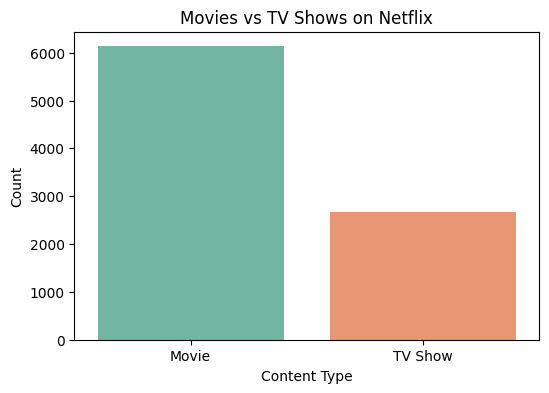

In [13]:
#movies vs tv shows
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df, palette='Set2')
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

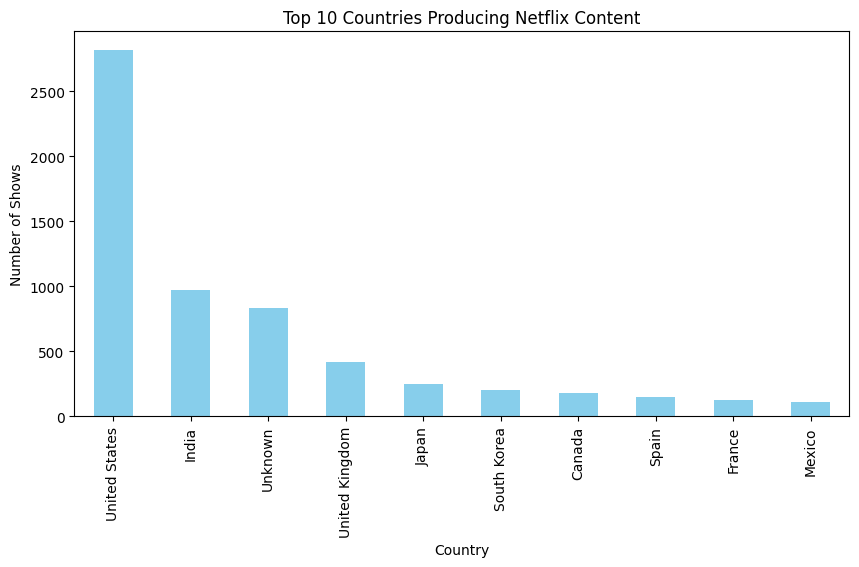

In [15]:
#top 10 countries producing content
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(10,5))
top_countries.plot(kind='bar', color='skyblue')
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Shows")
plt.show()


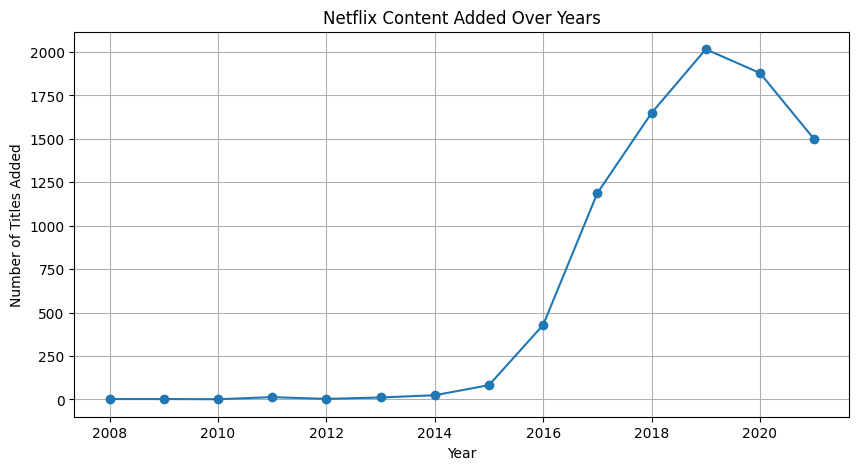

In [16]:
#content added over years
df['year_added'] = df['date_added'].dt.year
plt.figure(figsize=(10,5))
df['year_added'].value_counts().sort_index().plot(marker='o')
plt.title("Netflix Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.grid()
plt.show()

/tmp/ipykernel_5240/3857326827.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='rating',


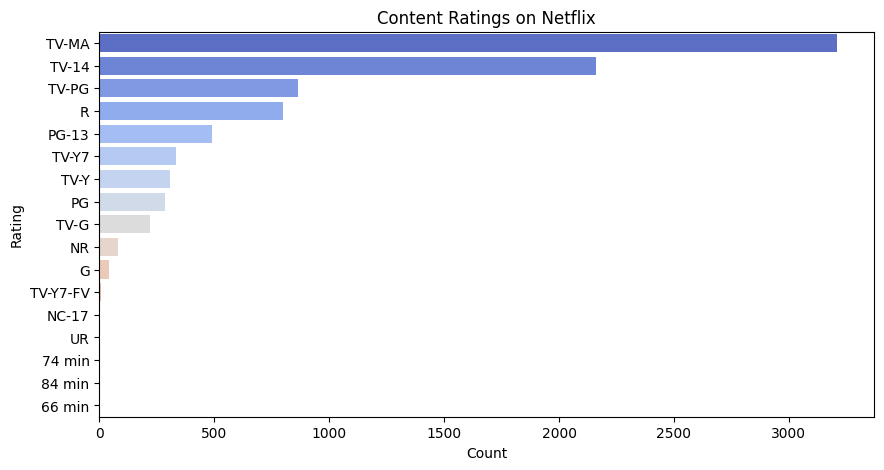

In [18]:
#most common ratings
plt.figure(figsize=(10,5))
sns.countplot(y='rating',
              data=df,
              order=df['rating'].value_counts().index,
              palette='coolwarm')

plt.title("Content Ratings on Netflix")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()


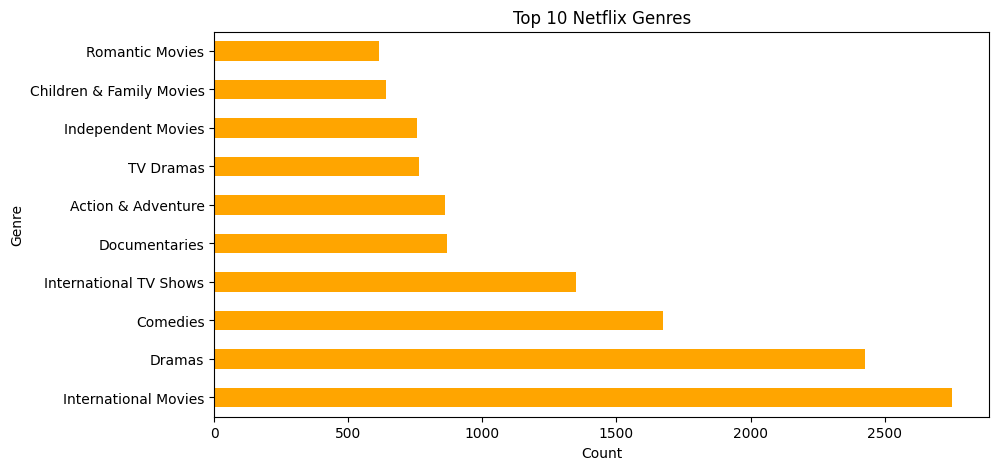

In [19]:
#top 10 generes
genres = df['listed_in'].str.split(', ', expand=True).stack()

plt.figure(figsize=(10,5))
genres.value_counts().head(10).plot(kind='barh', color='orange')

plt.title("Top 10 Netflix Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()